In [ ]:
pip install opencv-python numpy scikit-image

C:\Users\Sasi\AppData\Local\Temp\ipykernel_27424\68862216.py:34: UserWarning: Use keyword parameter `sigmas` instead of `scale_range` and `scale_range` which will be removed in version 0.17.
  veins = frangi(enhanced, scale_range=(1, 6), scale_step=1)


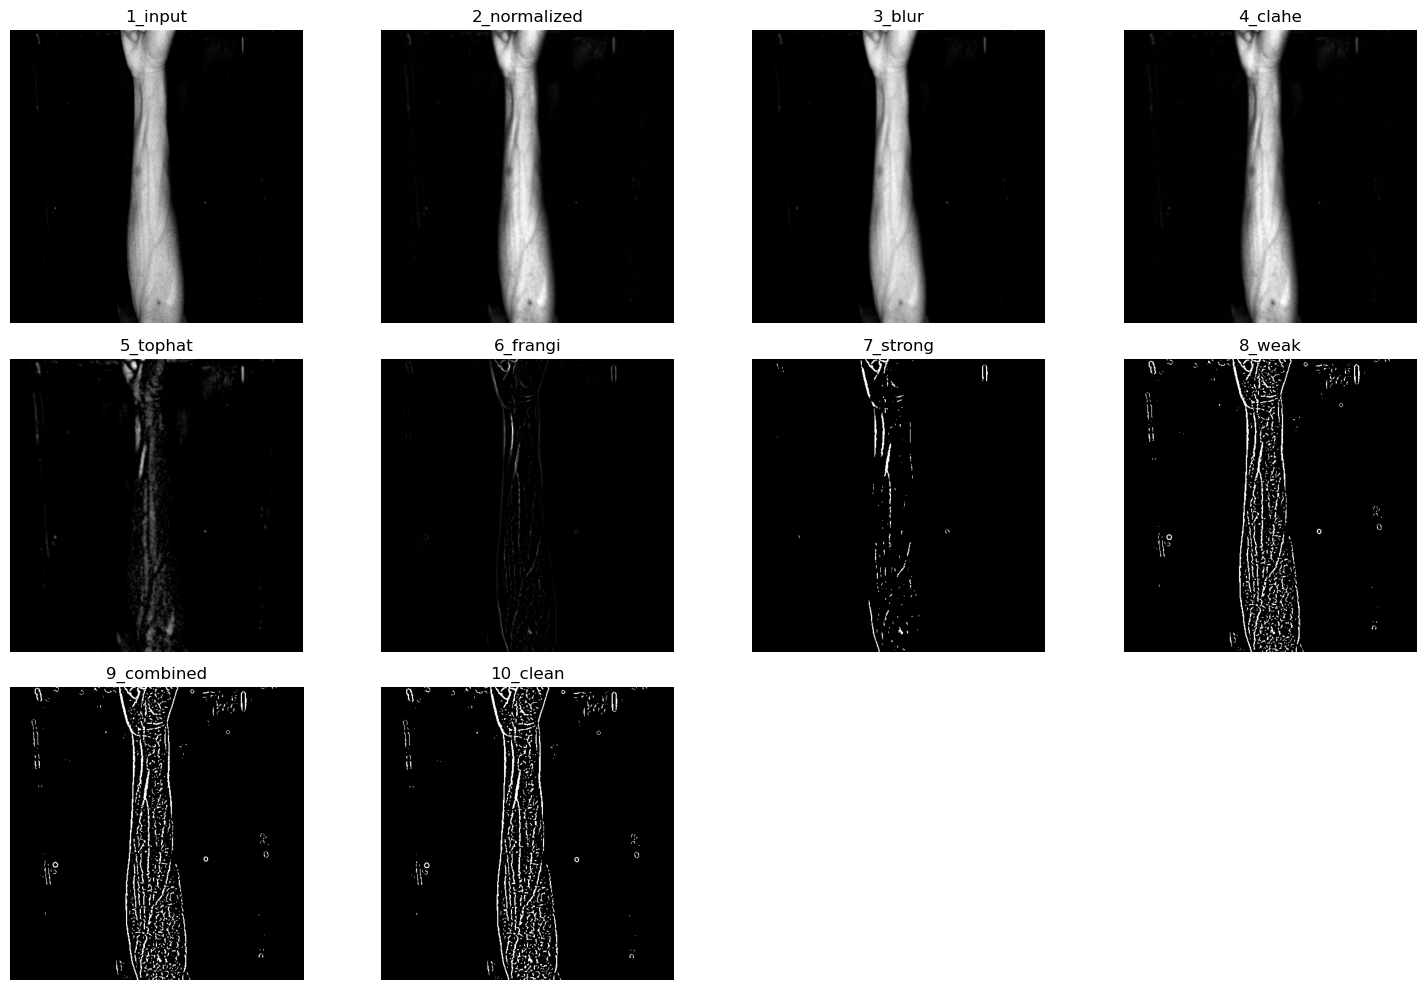

All step images saved successfully!


In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.morphology import skeletonize

# Dictionary to store steps
steps = {}

# Load image
img = cv2.imread("00030 .jpg", 0)   # removed space bug
img = cv2.resize(img, (512, 512))
steps["1_input"] = img

# Normalize 
norm = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)
steps["2_normalized"] = norm

# Gaussian Blur
blur = cv2.GaussianBlur(img, (5, 5), 0)
steps["3_blur"] = blur

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(blur)
steps["4_clahe"] = enhanced

# Top-hat
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
tophat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)
steps["5_tophat"] = tophat

# Frangi
veins = frangi(enhanced, scale_range=(1, 6), scale_step=1)
veins = (veins * 255).astype(np.uint8)
steps["6_frangi"] = veins

# Strong (Otsu)
_, strong = cv2.threshold(veins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
steps["7_strong"] = strong

# Weak (Adaptive)
weak = cv2.adaptiveThreshold(
    veins, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 15, -2
)
steps["8_weak"] = weak

# Combine
combined = cv2.bitwise_or(strong, weak)
steps["9_combined"] = combined

# Morphology
kernel = np.ones((2,2), np.uint8)
clean = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
steps["10_clean"] = clean





# =========================
# SHOW ALL STEPS
# =========================
plt.figure(figsize=(15,10))

for i, (name, image) in enumerate(steps.items()):
    plt.subplot(3,4,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# SAVE ALL STEPS
# =========================
for name, image in steps.items():
    cv2.imwrite(f"{name}.png", image)

print("All step images saved successfully!")